## Utilisation d'un PINN comme méthode d'inversion

In [11]:
import jax
import jax.numpy as jnp
import functools
import numpy as np
import optax
import matplotlib.pyplot as plt
from data_load import WaveguideBoundaryData

In [12]:
print(jax.devices())

[CudaDevice(id=0)]


**Data loading**

In [13]:
#Domaine Omega : [-1,1]x[0,0.6]
#conditions de neuman en y=0 et y=0.6
H = 0.6
L = 1

data_loader_left = WaveguideBoundaryData('data/pinn_boundary_left_n0.csv')
data_loader_right = WaveguideBoundaryData('data/pinn_boundary_right_n0.csv')

X_left, Y_left, U_re_left, U_im_left, freq = data_loader_left.get_training_data()
X_right, Y_right, U_re_right, U_im_right, _ = data_loader_right.get_training_data()

Y_left = Y_left[freq[0]]
Y_right = Y_right[freq[0]]

**Normalisation des outputs et inputs**

In [14]:
# x est déjà dans [-1,1]
#on passe y et u au bord dans [-1,1]

Y_norm = jnp.max(Y_left)
Y_left=2*Y_left/Y_norm - 1
Y_right=2*Y_right/Y_norm - 1

U_norm = {}
U_left_norm = {}
U_right_norm = {}

for f in freq:
    U_norm[f] = np.sqrt(jnp.max(np.concatenate((U_re_left[f]**2 + U_im_left[f]**2,U_re_right[f]**2 + U_im_right[f]**2))))
    U_re_left[f]/=U_norm[f]
    U_im_left[f]/=U_norm[f]
    U_re_right[f]/=U_norm[f]
    U_im_right[f]/=U_norm[f]
    U_left_norm[f] = jnp.stack([U_re_left[f],U_im_left[f]], axis=1)
    U_right_norm[f] = jnp.stack([U_re_right[f],U_im_right[f]], axis=1)

**Initialisation des paramètres**

In [15]:
key = jax.random.key(0) # initialisation de la PRNG

#Initialisation des Fouriers Features
#On connait notre kmax car c0 = 340
fmax = jnp.max(freq)
c0 = 340
cmax = 1.1 * c0
cmin = 340/6
contrast = 1 #pour l'instant
kmax = 2*jnp.pi*fmax*contrast/340
m = 64

key, subkey = jax.random.split(key)
B = jax.random.uniform(subkey, (m, 2), minval=-kmax, maxval=kmax)

def gamma(x,y):
    x_phys = x * L 
    y_phys = (y + 1.0) * H / 2.0
    v_phys = jnp.array([x_phys, y_phys])

    return jnp.concatenate([jnp.cos(B@v_phys),jnp.sin(B@v_phys)])

#Il faut initialiser les points de quadratures

N_modes = int(np.round(2*H*fmax/c0)) + 5

n_gauss_legendre = 20

y_gauss_legendre, w_gauss_legendre = np.polynomial.legendre.leggauss(n_gauss_legendre)

# Entrée (x, y)
n_input = 2

n_layers_uv = [2*m, 64, 64, 64, 2]
n_layers_c = [n_input, 64, 1]

#Initialisation de Xavier

def init_layers(key, n_layers):
    layers = []
    for i in range(len(n_layers)-1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey, (n_layers[i], n_layers[i+1])) / jnp.sqrt(n_layers[i])
        b = jnp.zeros(n_layers[i+1])
        layers.append({"W": W, "b": b})
    return layers, key

key, subkey_uv, subkey_c = jax.random.split(key, 3)

layers_uv, key = init_layers(subkey_uv, n_layers_uv)
layers_c, key = init_layers(subkey_c, n_layers_c)

**Le Forward**

In [ ]:
def forward_func(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = Z @ layers[-1]["W"] + layers[-1]["b"]
    return Z

def forward_params(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = cmin + (cmax-cmin) * jax.nn.sigmoid(Z @ layers[-1]["W"] + layers[-1]["b"])
    return Z.squeeze()

**La loss function**

In [17]:
y_quad = (y_gauss_legendre + 1.0) * H / 2.0
w_quad = w_gauss_legendre * H / 2.0
n_modes = jnp.arange(N_modes)
a_n = jnp.sqrt(2/H) * jnp.ones(N_modes)
a_n = a_n.at[0].set(jnp.sqrt(1/H))
C_quad = a_n[:, None] * jnp.cos(n_modes[:, None] * jnp.pi * y_quad[None, :] / H)

def loss_fn(layers_uv, layers_c, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val, weights = (1,1,1)):

    def uv(x,y):
        features = gamma(x, y)
        return forward_func(layers_uv, features)
    
    def k(x,y):
        return 2*jnp.pi*f/forward_params(layers_c, jnp.array([x, y]))
    
    def uv_x(x, y):
        return jax.jacfwd(uv, argnums=0)(x, y)/L
    
    def uv_y(x, y):
        return jax.jacfwd(uv, argnums=1)(x, y)*(2/H)

    def pde_residual(x, y):
        uv_xx = jax.jacfwd(jax.jacfwd(uv, argnums=0), argnums=0)(x, y) / L**2
        uv_yy = jax.jacfwd(jax.jacfwd(uv, argnums=1), argnums=1)(x, y)*(2/H)**2
        return uv_xx + uv_yy + k(x,y)**2*uv(x,y)
    
    k0 = 2*jnp.pi*f/c0

    beta_n = jnp.sqrt(k0**2 - (n_modes*jnp.pi/H)**2 +0j)
    
    def compute_dtn_loss(x_bnd, y_data, sign, A_inc=None):
        uv_quad = jax.vmap(uv, in_axes=(None, 0))(x_bnd, y_gauss_legendre)
        U_quad_complex = uv_quad[:, 0] + 1j * uv_quad[:, 1]
        
        u_n = C_quad @ (w_quad * U_quad_complex)
        
        dtn_n = sign * 1j * beta_n * u_n
        if A_inc is not None:
            dtn_n = dtn_n + 2j * beta_n * A_inc
        
        def DtN_eval(y_eval):
            C_y = a_n * jnp.cos(n_modes * jnp.pi * (y_eval+1)/2)
            return C_y @ dtn_n
            
        dtn_pred_complex = jax.vmap(DtN_eval)(y_data)
        
        dtn_actual = jax.vmap(uv_x, in_axes=(None, 0))(x_bnd, y_data)
        dtn_actual_complex = dtn_actual[:, 0] + 1j * dtn_actual[:, 1]
        
        return jnp.mean(jnp.abs(dtn_pred_complex - dtn_actual_complex)**2)

    A_inc_left = jnp.zeros(N_modes, dtype=jnp.complex64)
    amplitude_incidente = jnp.exp(-1j * beta_n[0] * L) / u_norm_val
    A_inc_left = A_inc_left.at[0].set(amplitude_incidente)
    #residual
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0, 0))
    pde_loss = jnp.mean(vmap_pde_residual(x, y)**2)
    #boundary conditions
    dtn_loss_left = compute_dtn_loss(-1.0, y, sign=-1, A_inc=A_inc_left)
    dtn_loss_right = compute_dtn_loss(1.0, y, sign=1, A_inc=None)
    neum_loss = jnp.mean(jax.vmap(uv_y, in_axes=(0, None))(x, 1.0)**2 + jax.vmap(uv_y, in_axes=(0, None))(x, -1.0)**2)
    bc_loss = neum_loss + dtn_loss_left + dtn_loss_right
    #data
    vmap_uv_y = jax.vmap(uv, (None,0))
    data_loss = jnp.mean((vmap_uv_y(-1.0,y_bnd_left) - target_u_left)**2+(vmap_uv_y(1.0,y_bnd_right) - target_u_right)**2)

    total_loss = weights[0]*pde_loss + weights[1]*bc_loss + weights[2]*data_loss
    
    return total_loss, (weights[0]*pde_loss, weights[1]*bc_loss, weights[2]*data_loss)

**Le training**

In [ ]:
lr_u = 3e-4
lr_c = 3e-5

optimizer_uv = optax.adam(lr_u)
optimizer_c = optax.adam(lr_c)

@functools.partial(jax.jit, static_argnames=('N',))
def train_step(layers_uv, layers_c, opt_state_uv, opt_state_c, N, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm, current_weights, key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
    y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
    
    (loss, _), (grads_uv, grads_c) = jax.value_and_grad(loss_fn, argnums=(0,1), has_aux=True)(
        layers_uv, layers_c, x, y, f_val, target_left, target_right, 
        y_bnd_left, y_bnd_right, u_norm, current_weights
    )
    
    updates_uv, opt_state_uv = optimizer_uv.update(grads_uv, opt_state_uv, layers_uv)
    layers_uv = optax.apply_updates(layers_uv, updates_uv)

    updates_c, opt_state_c = optimizer_c.update(grads_c, opt_state_c, layers_c)
    layers_c = optax.apply_updates(layers_c, updates_c)
    
    return layers_uv, layers_c, opt_state_uv, opt_state_c, loss, key

@jax.jit
def eval_step(layers_uv, layers_c, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val):
    return loss_fn(layers_uv, layers_c, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val, weights = (1,1,1))

def train(layers_uv, layers_c, N, max_steps_per_freq, freqs, eval_interval, loss_threshold, patience, key):

    optimizer_uv = optax.adam(lr_u)
    optimizer_c = optax.adam(lr_c)
    
    train_loss = []
    global_loss = []
    
    for current_freq in freqs:
        print(f"\n--- f = {current_freq} Hz ---")

        opt_state_uv = optimizer_uv.init(layers_uv)
        opt_state_c = optimizer_c.init(layers_c,)
        
        loss_thresh = []
        eval_count = 0
        weights = jnp.array([1.0, 100.0, 1000.0])

        for step in range(max_steps_per_freq):
            layers_uv, layers_c, opt_state_uv, opt_state_c, _, key = train_step(
                layers_uv, layers_c, opt_state_uv, opt_state_c, N, current_freq, 
                U_left_norm[current_freq], U_right_norm[current_freq], 
                Y_left, Y_right, U_norm[current_freq], weights, key
            )
            if step % eval_interval == 0:
                key, subkey1, subkey2 = jax.random.split(key, 3)
                x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
                y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
                loss, (pde_loss, bc_loss, data_loss) = eval_step(
                    layers_uv, layers_c, x, y, current_freq, U_left_norm[current_freq],  
                    U_right_norm[current_freq], Y_left, Y_right, U_norm[current_freq]
                )
                
                train_loss.append((pde_loss.item(), bc_loss.item(), data_loss.item()))
                global_loss.append(loss.item())
                loss_thresh.append(loss.item())
                
                print(f"Step {step} | pde {pde_loss:.2e} | dtn {bc_loss:.2e} | data {data_loss:.2e} | total {loss:.2e} | weights {weights}")
                
                if eval_count > patience:
                    recent_std = jnp.std(jnp.array(loss_thresh[-patience:]))
                    if recent_std < loss_threshold:
                        print(f"Plateau std : {recent_std:.2e})")
                        break
                eval_count += 1
                
    return layers_uv, layers_c, key, train_loss

**La phase d'entrainement**

In [19]:
max_steps_per_freq = 200000
eval_interval = max_steps_per_freq//60
N = 1000
loss_threshold = 1e-3
patience = 5

freq = np.array([200.0,400.0])

key, subkey = jax.random.split(key)
layers_uv, layers_c, key, train_loss = train(layers_uv, layers_c, N, max_steps_per_freq, freq, eval_interval, loss_threshold, patience, key)


--- f = 200.0 Hz ---
Step 0 | pde 1.00e+05 | dtn 5.11e+02 | data 1.01e+00 | total 1.01e+05 | weights [   1.  100. 1000.]
Step 3333 | pde 1.19e+02 | dtn 7.81e-02 | data 1.80e-02 | total 1.19e+02 | weights [   1.  100. 1000.]
Step 6666 | pde 3.70e+01 | dtn 3.03e-02 | data 1.21e-03 | total 3.70e+01 | weights [   1.  100. 1000.]
Step 9999 | pde 4.90e+00 | dtn 5.46e-03 | data 1.12e-04 | total 4.90e+00 | weights [   1.  100. 1000.]
Step 13332 | pde 3.60e+00 | dtn 4.15e-03 | data 7.80e-05 | total 3.60e+00 | weights [   1.  100. 1000.]
Step 16665 | pde 3.10e+00 | dtn 4.15e-03 | data 1.09e-04 | total 3.10e+00 | weights [   1.  100. 1000.]
Step 19998 | pde 2.68e+00 | dtn 3.75e-03 | data 9.92e-05 | total 2.68e+00 | weights [   1.  100. 1000.]
Step 23331 | pde 2.51e+00 | dtn 3.05e-03 | data 8.38e-05 | total 2.52e+00 | weights [   1.  100. 1000.]
Step 26664 | pde 2.32e+00 | dtn 3.07e-03 | data 6.89e-05 | total 2.33e+00 | weights [   1.  100. 1000.]
Step 29997 | pde 1.98e+00 | dtn 2.50e-03 | data 5

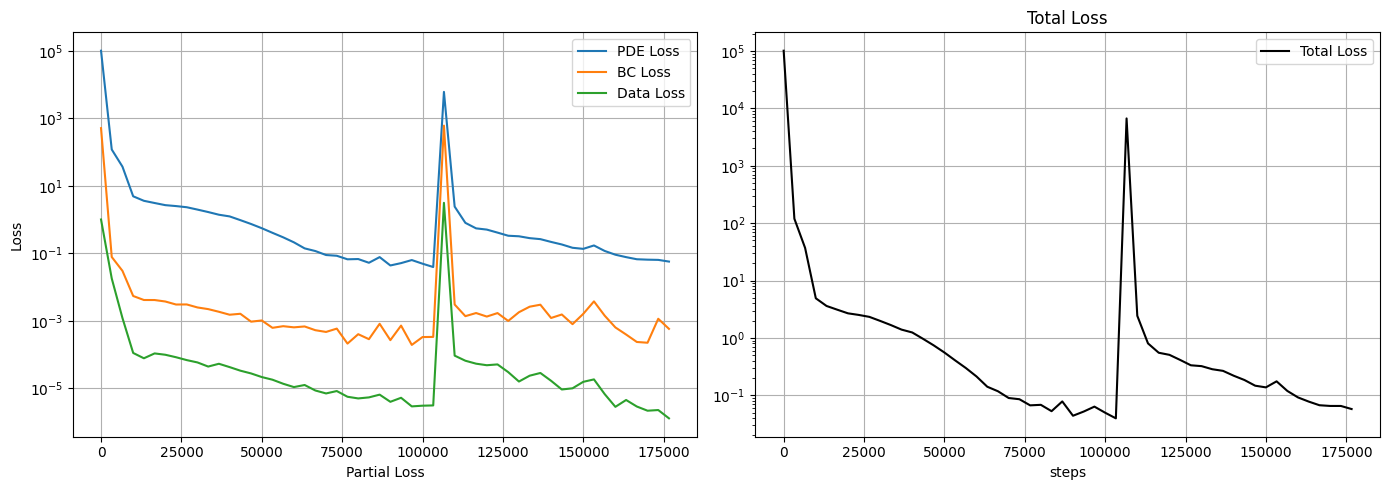

In [20]:
train_loss_arr = np.array(train_loss)
pde_losses = train_loss_arr[:, 0]
dtn_losses = train_loss_arr[:, 1]
data_losses = train_loss_arr[:, 2]
total_losses = pde_losses + dtn_losses + data_losses

x_axis = eval_interval * np.arange(len(train_loss))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(x_axis, pde_losses, label="PDE Loss")
ax1.semilogy(x_axis, dtn_losses, label="BC Loss")
ax1.semilogy(x_axis, data_losses, label="Data Loss")

ax2.semilogy(x_axis, total_losses, label="Total Loss", color='black')

ax1.set_xlabel("Partial Loss")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Total Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig/2D_Wave_guide_metrics_w_an.pdf')
plt.show()

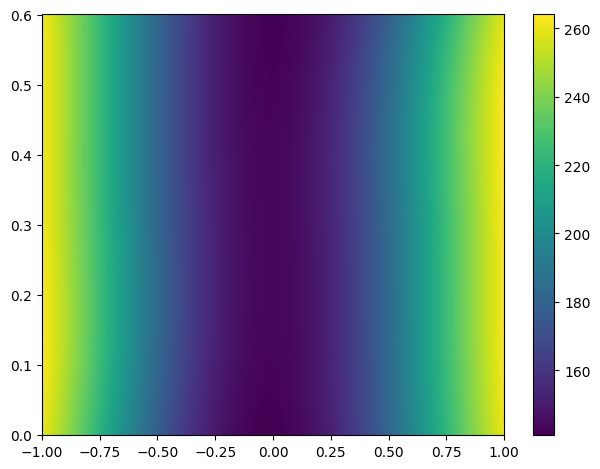

In [ ]:
def c(x,y):
    return forward_params(layers_c, jnp.array([x, y]))

x = np.linspace(-1,1,1000)
y = np.linspace(0,0.6,500)

c_grid = jax.vmap(jax.vmap(c, in_axes=(0, None)), in_axes=(None, 0))(x,2*y/H-1)

plt.pcolormesh(x, y, c_grid)
plt.colorbar()
plt.tight_layout()
plt.savefig('fig/2D_Wave_guide_c_map.pdf')
plt.show()